# Fashion MNIST 의류 이미지 분류

## 실습 목표
본 실습에서는 Fashion MNIST 데이터셋을 이용하여 다층 퍼셉트론(MLP) 기반 분류 모델을 구현하고, 학습 결과를 비교 및 분석한다.

## 실습 내용
- Fashion MNIST 데이터셋 불러오기
- 데이터 전처리 및 학습/검증 데이터 분리
- 다층 퍼셉트론 모델 구성
- 두 가지 모델 학습 결과 비교
- 손실(loss) 및 정확도(accuracy) 그래프 시각화
- 모델 성능 분석

---

#### 1] 라이브러리 import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from typing import Any
from tensorflow.keras.datasets.fashion_mnist import load_data
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

#### 2] 상수 정의

In [2]:
RANDOM_STATE = 777
NUM_CLASSES = 10
EPOCHS = 30
BATCH_SIZE = 128
VALIDATION_RATIO = 0.3

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

## 데이터셋 소개

- Fashion MNIST는 의류 이미지로 구성된 대표적인 이미지 분류 데이터셋이다.  
- 각 이미지는 `28 × 28` 크기의 흑백 이미지이며, 총 10개의 클래스로 구성된다.
- 기존 MNIST가 손글씨 숫자를 분류하는 데이터셋이라면, Fashion MNIST는 의류 종류를 분류하는 데이터셋으로 상대적으로 더 복잡한 분류 문제를 제공한다.

##### Fashion MNIST 레이블 표

| 레이블 | 클래스 이름 |
|------:|-------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

#### 3] 데이터 준비 함수

##### 데이터 전처리

모델 학습을 위해 다음과 같은 전처리를 수행한다.

1. 픽셀 값을 `0 ~ 255` 범위에서 `0 ~ 1` 범위로 정규화
2. 레이블 데이터를 one-hot encoding 형태로 변환
3. 학습 데이터를 학습용(train)과 검증용(validation)으로 분리

이 과정을 통해 모델이 데이터를 더 안정적으로 학습할 수 있도록 한다.

In [3]:
def load_and_prepare_data(validation_ratio: float = VALIDATION_RATIO, random_state: int = RANDOM_STATE) -> tuple:
    (x_train, y_train), (x_test, y_test) = load_data()

    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    y_train = to_categorical(y_train, num_classes=NUM_CLASSES)
    y_test = to_categorical(y_test, num_classes=NUM_CLASSES)

    x_train, x_val, y_train, y_val = train_test_split(
        x_train,
        y_train,
        test_size=validation_ratio,
        random_state=random_state
    )

    return x_train, x_val, y_train, y_val, x_test, y_test

#### 4] 샘플 이미지 확인 함수

##### 샘플 이미지 확인

- 학습에 사용될 이미지 데이터를 시각적으로 확인하여 데이터가 정상적으로 불러와졌는지 점검한다.  
- 무작위로 선택한 샘플 이미지를 통해 각 클래스의 특징을 살펴볼 수 있다.

In [4]:
def show_random_samples(images: np.ndarray, labels: np.ndarray, class_names: list[str],
                            sample_size: int = 9, random_state: int = RANDOM_STATE) -> None:

    rng = np.random.default_rng(random_state)
    random_idx = rng.integers(0, len(images), size=sample_size)

    plt.figure(figsize=(6, 6))

    for i, idx in enumerate(random_idx):
        plt.subplot(3, 3, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[idx], cmap='gray')
        plt.xlabel(class_names[labels[idx]])

    plt.tight_layout()
    plt.show()

#### 5] 모델 생성 함수

##### 모델 구성

- 본 실습에서는 다층 퍼셉트론(MLP) 구조를 사용한다.  
- 입력 데이터는 `28 × 28` 형태의 이미지를 받아 Flatten 층을 통해 1차원 벡터로 변환한 후, 여러 개의 Dense 층을 통과하여 최종적으로 10개의 클래스에 대해 Softmax 확률값을 출력한다.
- 이번 실습에서는 은닉층의 구조가 서로 다른 두 모델을 구성하여 성능을 비교한다.

In [5]:
def build_dense_model(hidden_units: list[int]) -> Sequential:
    model = Sequential([
        Input(shape=(28, 28)),
        Flatten(),
        *[Dense(units, activation='relu') for units in hidden_units],
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

#### 6] 학습 함수

##### 모델 학습

두 모델 모두 동일한 학습 조건에서 학습을 수행한다.

- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Metric: Accuracy
- Epochs: 30
- Batch Size: 128

검증 데이터(validation data)를 함께 사용하여 epoch별 손실과 정확도를 추적한다.

In [6]:
def train_model(
    model: Sequential,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    epochs: int = EPOCHS,
    batch_size: int = BATCH_SIZE
):
    return model.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        verbose=0
    )

#### 7] 학습 결과 시각화 함수

##### 학습 결과 시각화

학습 과정에서 기록된 손실(loss)과 정확도(accuracy)를 그래프로 시각화하여 두 모델의 학습 추이를 비교한다.

이를 통해 다음과 같은 내용을 확인할 수 있다.

- 학습이 정상적으로 진행되는지 여부
- 과적합(overfitting) 발생 여부
- 모델 구조 차이에 따른 성능 차이

In [7]:
def plot_histories(histories: list[Any], model_names: list[str] | None = None) -> None:
    if not histories:
        raise ValueError('histories 리스트가 비어 있습니다.')
    
    n_models = len(histories)

    if model_names is None:
        model_names = [f'model_{i + 1}' for i in range(n_models)]

    if len(model_names) != n_models:
        raise ValueError('model_names 길이는 histories 길이와 같아야 합니다.')

    def get_acc_key(history_dict: dict) -> str:
        if 'accuracy' in history_dict:
            return 'accuracy'
        if 'acc' in history_dict:
            return 'acc'
        raise KeyError("history에 'accuracy' 또는 'acc'가 없습니다.")

    sns.set_theme(style='whitegrid', context='notebook')

    fig, axes = plt.subplots(n_models, 2, figsize=(13, 4 * n_models))

    if n_models == 1:
        axes = [axes]

    for i, (history, model_name) in enumerate(zip(histories, model_names)):
        hist = history.history
        acc_key = get_acc_key(hist)
        val_acc_key = f'val_{acc_key}'
        epochs = range(1, len(hist['loss']) + 1)

        sns.lineplot(x=list(epochs), y=hist[acc_key], ax=axes[i][0], label='train_accuracy')
        sns.lineplot(x=list(epochs), y=hist[val_acc_key], ax=axes[i][0], label='val_accuracy')
        axes[i][0].set_title(f'{model_name} Accuracy')
        axes[i][0].set_xlabel('Epochs')
        axes[i][0].set_ylabel('Accuracy')

        sns.lineplot(x=list(epochs), y=hist['loss'], ax=axes[i][1], label='train_loss')
        sns.lineplot(x=list(epochs), y=hist['val_loss'], ax=axes[i][1], label='val_loss')
        axes[i][1].set_title(f'{model_name} Loss')
        axes[i][1].set_xlabel('Epochs')
        axes[i][1].set_ylabel('Loss')

    plt.tight_layout()
    plt.show()

---

#### 데이터 로드 및 확인

전처리 함수를 이용하여 Fashion MNIST 데이터를 불러오고, 학습용·검증용·테스트용 데이터의 shape를 확인한다.

In [8]:
x_train, x_val, y_train, y_val, x_test, y_test = load_and_prepare_data()

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (42000, 28, 28)
y_train: (42000, 10)
x_val: (18000, 28, 28)
y_val: (18000, 10)
x_test: (10000, 28, 28)
y_test: (10000, 10)


#### 샘플 이미지 보기

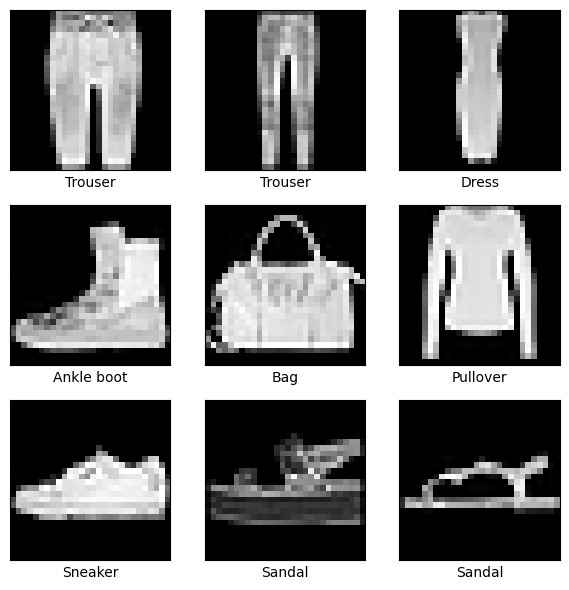

In [9]:
show_random_samples(
    images=x_train,
    labels=np.argmax(y_train, axis=1),
    class_names=CLASS_NAMES,
)

#### 모델 생성

##### 첫 번째 모델

- 첫 번째 모델은 비교적 단순한 구조의 다층 퍼셉트론 모델이다.  
- 은닉층을 `[64, 32]` 형태로 구성하여 Fashion MNIST 이미지 분류를 수행한다.
- 이 모델은 기본적인 분류 성능을 확인하기 위한 기준 모델(baseline model)의 역할을 한다.

##### 두 번째 모델

- 두 번째 모델은 첫 번째 모델보다 더 많은 은닉층과 뉴런 수를 가지는 구조이다.  
- 은닉층을 `[128, 64, 32]` 형태로 구성하여, 더 복잡한 특징을 학습할 수 있도록 설계하였다.
- 이를 통해 모델의 복잡도를 증가시켰을 때 학습 성능과 일반화 성능이 어떻게 달라지는지 확인하고자 한다.

In [10]:
first_model = build_dense_model([64, 32])
second_model = build_dense_model([128, 64, 32])

first_model.summary()
second_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

#### 모델 학습

In [11]:
first_history = train_model(first_model, x_train, y_train, x_val, y_val)
second_history = train_model(second_model, x_train, y_train, x_val, y_val)

#### 결과 비교 시각화

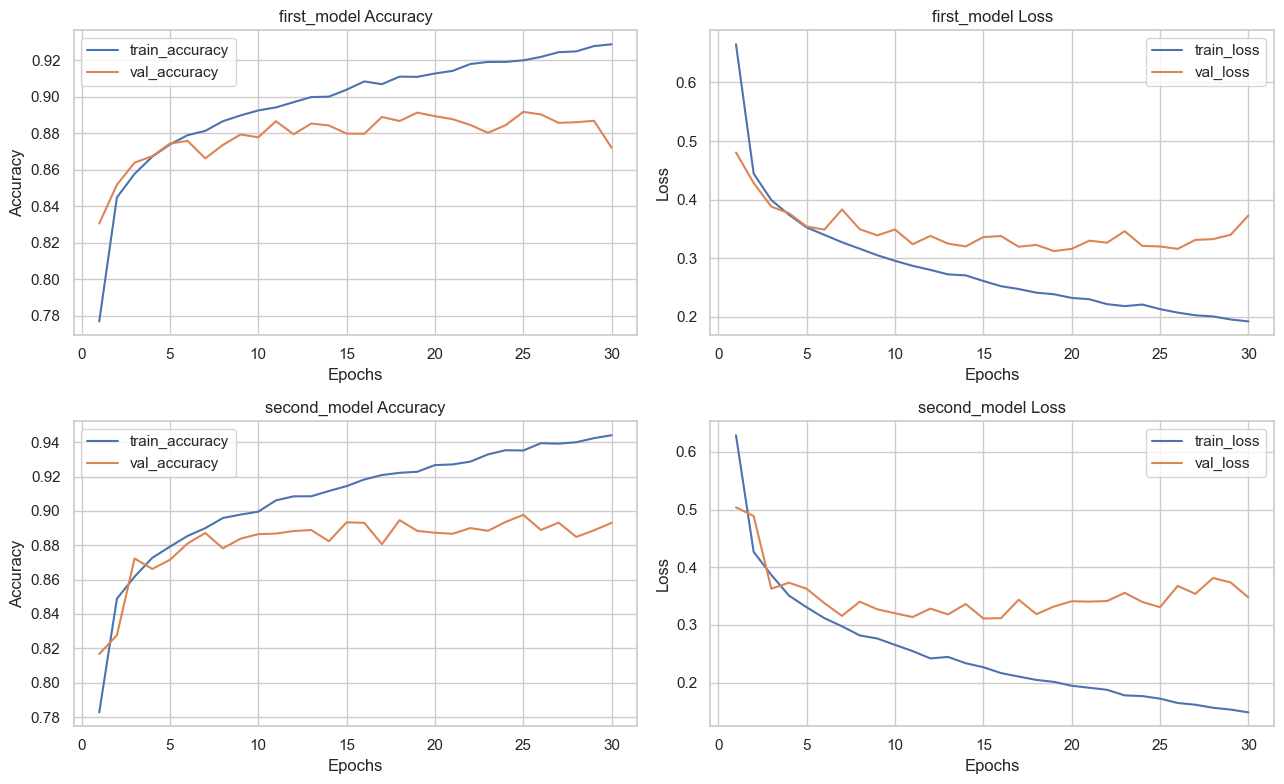

In [12]:
plot_histories(
    histories=[first_history, second_history],
    model_names=["first_model", "second_model"],
)

## 모델 학습 결과 분석

이번 실험에서는 `first_model`과 `second_model`의 학습 결과를 정확도(Accuracy)와 손실(Loss) 그래프로 비교하였다.

### 1. 전체적인 학습 경향
두 모델 모두 초반 epoch에서 train accuracy와 validation accuracy가 빠르게 상승하고, train loss와 validation loss가 감소하는 모습을 보였다. 이는 모델이 Fashion MNIST 데이터의 기본적인 패턴을 정상적으로 학습하고 있음을 의미한다.

### 2. 과적합(Overfitting) 경향
두 모델 모두 중반 이후부터 train accuracy는 계속 증가하고 train loss는 계속 감소하지만, validation accuracy는 일정 수준에서 정체되고 validation loss는 더 이상 뚜렷하게 감소하지 않거나 오히려 변동하는 모습을 보였다.  
이러한 결과는 학습이 진행될수록 훈련 데이터에 더 잘 맞춰지는 반면, 검증 데이터에 대한 일반화 성능은 크게 향상되지 않는 **과적합 경향**으로 해석할 수 있다.

### 3. first_model 분석
`first_model`은 train accuracy가 약 0.93 수준까지 증가하였고, validation accuracy는 약 0.88~0.89 수준에서 형성되었다.  
또한 train loss는 꾸준히 감소하였지만 validation loss는 초반 이후 큰 폭으로 개선되지 않고 일정 수준에서 유지되었다.  
즉, `first_model`은 비교적 안정적으로 학습되었지만, 일정 epoch 이후에는 추가 학습에 따른 성능 향상이 크지 않은 것으로 보인다.

### 4. second_model 분석
`second_model`은 `first_model`보다 더 높은 train accuracy와 더 낮은 train loss를 보였다. 이는 더 복잡한 모델 구조가 훈련 데이터에 대해 더 강한 학습 능력을 가졌음을 의미한다.  
하지만 validation accuracy는 `first_model`에 비해 큰 차이를 보이지 않았으며, validation loss는 다소 변동성이 더 크게 나타났다.  
따라서 `second_model`은 훈련 성능은 더 우수하지만, 검증 성능 측면에서는 `first_model` 대비 뚜렷한 개선이 나타나지 않았다.

### 5. 모델 비교
정리하면, `second_model`은 훈련 데이터에 대해서는 더 높은 성능을 보였지만, 검증 데이터에 대한 일반화 성능은 `first_model`과 큰 차이가 없었다.  
즉, 모델의 복잡도를 증가시켰다고 해서 반드시 검증 성능이 함께 향상되는 것은 아니며, 이번 결과에서는 오히려 과적합 경향이 더 뚜렷하게 나타났다고 볼 수 있다.

### 6. 결론
이번 실험을 통해 두 모델 모두 Fashion MNIST 분류 문제를 잘 학습하였지만, epoch가 증가할수록 과적합 경향이 나타남을 확인할 수 있었다.  
특히 `second_model`은 더 높은 훈련 성능을 보였지만 검증 성능 개선은 제한적이었다.  
따라서 이후에는 epoch 수를 무작정 늘리기보다는 **Early Stopping**, **Dropout**, **Batch Normalization** 등의 방법을 적용하여 일반화 성능을 개선하는 방향이 더 적절할 것으로 판단된다.